# 为什么要沿着费米线积分

这个 notebook 用两个简单例子解释 graphene 代码里的费米线积分：

1. 数学里的普通线积分：先有一条曲线，再沿曲线累加。
2. 物理里的费米线积分：二维 `k` 空间中，`E(k)=mu` 是一条线，`delta(mu-E(k))` 会把二维积分压到这条线上。

核心结论是：二维体系里只关心费米能附近的电子态时，积分会变成沿费米线的线积分。

## 1. 普通线积分：沿一条圆周累加

假设有一个圆：

$$
x^2+y^2=R^2
$$

如果我们要沿圆周积分一个函数 `F(x,y)`：

$$
\oint F(x,y)\,ds
$$

数值上就是：先拿到圆周上的很多点，然后把相邻点连成小线段，每一段长度是 `ds`，最后做求和：

$$
\oint F ds \approx \sum_i F(x_i,y_i)\,ds_i
$$

In [11]:
import numpy as np
import matplotlib.pyplot as plt

R = 1
num_points = 200
theta = np.linspace(0.0, 2.0 * np.pi, num_points, endpoint=False)

# 圆周上的点坐标
x = R * np.cos(theta)
y = R * np.sin(theta)
points = np.column_stack([x, y])

# 闭合曲线：把第一个点追加到最后
closed_points = np.vstack([points, points[0]])

# 每一小段的长度 ds_i = |p_{i+1} - p_i|
ds = np.linalg.norm(closed_points[1:] - closed_points[:-1], axis=1)

print("点的数量 =", len(points))
print("ds.shape =", ds.shape)
print("数值圆周长 =", ds.sum())
print("解析圆周长 =", 2.0 * np.pi * R)

点的数量 = 200
ds.shape = (200,)
数值圆周长 = 6.282926924728271
解析圆周长 = 6.283185307179586


如果 `F(x,y)=1`，那么线积分就是圆周长：

$$
\oint 1\,ds=2\pi R
$$

这和代码里的 `np.sum(ds)` 是同一件事。

In [12]:
F = np.ones_like(ds)
line_integral = np.sum(F * ds)

print("integral F ds, F=1 =", line_integral)

integral F ds, F=1 = 6.282926924728271


现在换一个非均匀函数，例如：

$$
F(x,y)=1+x
$$

做法还是一样：在每一小段中点采样 `F`，再乘以该段长度 `ds`。

In [13]:
mid_points = 0.5 * (closed_points[:-1] + closed_points[1:])
F_mid = 1.0 + mid_points[:, 0]
line_integral_F = np.sum(F_mid * ds)

print("integral (1+x) ds =", line_integral_F)
print("解析上应该等于 2*pi*R，因为圆周上 x 的积分为 0:", 2.0 * np.pi * R)

integral (1+x) ds = 6.282926924728271
解析上应该等于 2*pi*R，因为圆周上 x 的积分为 0: 6.283185307179586


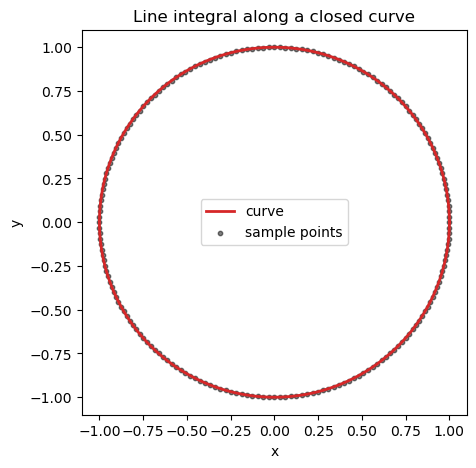

In [14]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(closed_points[:, 0], closed_points[:, 1], color="tab:red", lw=2, label="curve")
ax.scatter(points[:, 0], points[:, 1], s=10, color="black", alpha=0.5, label="sample points")
ax.set_aspect("equal")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Line integral along a closed curve")
ax.legend()
plt.show()

## 2. 费米线就是 `E(k)=mu` 这条等值线

现在把 `(x,y)` 换成二维倒空间坐标 `(k_x,k_y)`。

定义一个非常简单的“能带”：

$$
E(k_x,k_y)=k_x^2+k_y^2
$$

如果化学势是 `mu`，那么费米线由

$$
E(k_x,k_y)=\mu
$$

给出。对于这个例子，它就是一个半径 $\sqrt{\mu}$ 的圆。

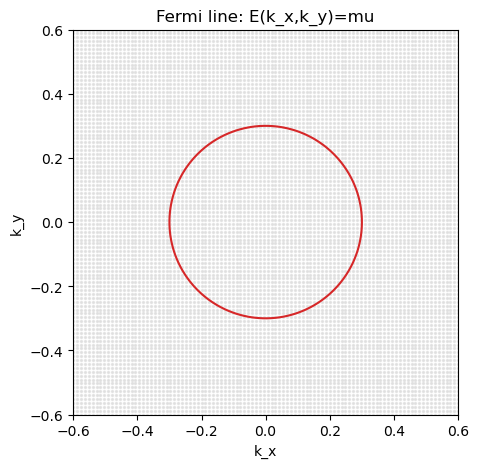

费米线片段数量 = 1
第一条费米线的点数 = 201


In [15]:
mesh_size = 100
kx = np.linspace(-0.6, 0.6, mesh_size)
ky = np.linspace(-0.6, 0.6, mesh_size)
kkx, kky = np.meshgrid(kx, ky, indexing="ij")

energy = kkx**2 + kky**2
mu = 0.09

fig, ax = plt.subplots(figsize=(5, 5))
contour = ax.contour(kkx, kky, energy, levels=[mu], colors="tab:red")
ax.scatter(kkx, kky, s=2, color="lightgray", alpha=0.5)
ax.set_aspect("equal")
ax.set_xlabel("k_x")
ax.set_ylabel("k_y")
ax.set_title("Fermi line: E(k_x,k_y)=mu")
plt.show()

segments = [seg for seg in contour.allsegs[0] if len(seg) >= 2]
print("费米线片段数量 =", len(segments))
print("第一条费米线的点数 =", len(segments[0]))

这里红线就是 `segments[0]` 里面的点连起来的曲线。

graphene 代码中的 `segments_reduced` 与这里的 `segments` 是同一类对象：它们都是费米线上的离散点坐标。

## 3. 为什么二维积分会变成沿费米线积分

很多费米面物理量包含下面这种二维积分：

$$
\int d^2k\,\delta(\mu-E(k))F(k)
$$

`delta(mu-E(k))` 的作用是只保留能量等于 `mu` 的点，也就是费米线上的点。

数学上有标准变换：

$$
\int d^2k\,\delta(\mu-E(k))F(k)
=
\oint_{E(k)=\mu}\frac{ds}{|\nabla_k E(k)|}F(k)
$$

所以二维积分不是对整个平面求和，而是被 delta 函数压缩到了费米线。

对于简单能带 $E=k_x^2+k_y^2$，有：

$$
|\nabla_k E|=2\sqrt{k_x^2+k_y^2}=2\sqrt{\mu}
$$

在费米线圆周上它是常数。如果取 `F(k)=1`，那么：

$$
\oint \frac{ds}{|\nabla_k E|}
=
\frac{2\pi\sqrt{\mu}}{2\sqrt{\mu}}
=
\pi
$$

下面用离散费米线点数值验证。

In [17]:
seg = segments[0]

# contour 返回的线通常已经接近闭合；这里显式闭合，保证最后一段也算进去
if np.linalg.norm(seg[0] - seg[-1]) > 1e-12:
    seg = np.vstack([seg, seg[0]])

mid = 0.5 * (seg[:-1] + seg[1:])
ds = np.linalg.norm(seg[1:] - seg[:-1], axis=1)

grad_norm = 2.0 * np.sqrt(mid[:, 0]**2 + mid[:, 1]**2)
integral_delta = np.sum(ds / grad_norm)

print("数值 integral ds/|grad E| =", integral_delta)
print("解析结果 pi =", np.pi)

数值 integral ds/|grad E| = 3.142035103785437
解析结果 pi = 3.141592653589793


这就是 graphene 代码里为什么会出现：

```python
total_dos += np.sum(ds / safe_velocity)
```

因为二维 DOS 里有 `delta(mu-E(k))`，它会变成费米线上的 `ds / |grad E|`。

## 4. 和 graphene 代码对应

graphene 代码中：

```python
seg_cart = reduced_k_to_cartesian(seg, recip_lat_vecs)
mid_reduced = 0.5 * (seg[:-1] + seg[1:])
ds = np.linalg.norm(seg_cart[1:] - seg_cart[:-1], axis=1)
sampled = evaluate_band_quantities_on_points(model, mid_reduced, recip_lat_vecs)
```

对应本 demo：

```python
mid = 0.5 * (seg[:-1] + seg[1:])
ds = np.linalg.norm(seg[1:] - seg[:-1], axis=1)
grad_norm = |grad E(mid)|
```

区别是 graphene 的 `E(k)` 是真实两带 TB 模型下能带，不是简单的 `kx^2+ky^2`。同时 graphene 还会在费米线中点上计算 `gap` 和 `metric_trace`，用于：

```text
lambda_E   ~ integral_FS ds * |grad E|
lambda_geo ~ integral_FS ds * gap^2 * Tr(g) / |grad E|
lambda_topo 的分母 ~ integral_FS ds * |grad E| / gap^2
```

所以你说的“先拿到 k 点倒空间坐标，然后沿着这些坐标积分”是对的。更精确地说：先拿到费米线上的 k 点坐标，再把这些点连成小线段，用 `sum F(k_mid) * ds` 近似线积分。

## 5. 回到论文：哪里体现了必须沿费米线积分

前面的例子只是数学演示。现在把它对应到论文里的 graphene EPC 公式。

论文最开始不是直接写线积分，而是写含有 delta 函数的 `k` 空间求和/积分。核心结构是：

$$
\sum_k \delta(\mu-E_n(k)) F(k)
$$

或者连续极限下：

$$
\int d^2k\,\delta(\mu-E_n(k))F(k)
$$

这里的 `delta(mu-E_n(k))` 是关键。它的作用是只保留满足：

$$
E_n(k)=\mu
$$

的那些 `k` 点。这个集合就是 Fermi surface。石墨烯是二维体系，所以 Fermi surface 是一条线，即费米线。

因此论文中的 `delta(mu-E)` 自动把二维 `k` 空间积分压缩成了沿费米线的积分。

## 6. 论文公式到费米线积分的变换

标准数学变换是：

$$
\int d^2k\,\delta(\mu-E(k))F(k)
=
\oint_{E(k)=\mu} \frac{ds}{|\nabla_k E(k)|}F(k)
$$

左边是二维区域积分；右边是沿等能线 `E(k)=mu` 的线积分。

每个符号的含义：

- `E(k)=mu`：费米线。
- `ds`：费米线上一小段弧长。
- `|grad_k E|`：能量垂直穿过费米线时变化的快慢。
- `1/|grad_k E|`：delta 函数变量替换产生的 Jacobian。

这就是为什么代码里既要提取费米线坐标，也要计算每一段的 `ds` 和每个中点的 `velocity_norm`。

## 7. 对应 graphene 论文中的 lambda 公式

在 graphene 部分，论文最终写成类似下面的形式。色散项：

$$
\lambda_E
=
\frac{\Omega\gamma^2}{(2\pi)^2 m_C\langle\omega^2\rangle}
\oint_{FS} d\sigma_k\, |\nabla_k E_{n_F}(k)|
$$

几何项：

$$
\lambda_{geo}
=
\frac{\Omega\gamma^2}{(2\pi)^2 m_C\langle\omega^2\rangle}
\oint_{FS} d\sigma_k
\frac{\Delta E^2(k)\,\mathrm{Tr}\,g_{n_F}(k)}{|\nabla_k E_{n_F}(k)|}
$$

拓扑下界：

$$
\lambda_{topo}
=
\frac{\Omega\gamma^2}{4m_C\langle\omega^2\rangle}
\frac{(|W_K|+|W_{K'}|)^2}
{\oint_{FS} d\sigma_k\, |\nabla_k E_{n_F}(k)|/\Delta E^2(k)}
$$

这里已经明确出现了 `oint_FS`，也就是沿 Fermi surface 积分。石墨烯是二维体系，所以代码中就是沿费米线积分。

## 8. 这些公式在代码中对应哪几行

代码中先用 `extract_fermi_surface_segments()` 或 `extract_dirac_pocket_segments()` 得到费米线点坐标：

```python
segments_reduced = [...]
```

每个 `seg` 是一条费米线上的离散点。接着在 `integrate_fermi_surface_observables()` 中做线积分：

```python
seg_cart = reduced_k_to_cartesian(seg, recip_lat_vecs)
mid_reduced = 0.5 * (seg[:-1] + seg[1:])
ds = np.linalg.norm(seg_cart[1:] - seg_cart[:-1], axis=1)
sampled = evaluate_band_quantities_on_points(model, mid_reduced, recip_lat_vecs)
```

这些行的意思是：

- `seg_cart`：把费米线点转成真实倒空间坐标。
- `mid_reduced`：取每一小段的中点。
- `ds`：计算每一小段弧长，对应论文里的 `d sigma_k`。
- `sampled`：在中点计算 `Delta E`、`Tr g`、`|grad E|`。

然后四个积分核直接对应论文公式：

```python
total_dos += np.sum(ds / safe_velocity)
total_lambda_e += np.sum(ds * safe_velocity)
total_lambda_geo += np.sum(ds * safe_gap_sq * sampled["metric_trace"] / safe_velocity)
total_fs_inv_gap += np.sum(ds * safe_velocity / safe_gap_sq)
```

对应关系：

- `ds / safe_velocity` 对应 `d sigma_k / |grad E|`。
- `ds * safe_velocity` 对应 `d sigma_k |grad E|`，用于 `lambda_E`。
- `ds * gap^2 * Tr(g) / velocity` 对应 `lambda_geo` 的积分核。
- `ds * velocity / gap^2` 对应 `lambda_topo` 分母。

## 9. 最后一句话

你可以这样理解整个流程：

```text
论文中的 delta(mu-E(k))
    -> 只保留 E(k)=mu 的 k 点
    -> 这些点组成费米线
    -> 二维 k 积分变成沿费米线的线积分
    -> 代码用 segments 保存费米线点
    -> 用 sum F(mid) * ds 近似论文里的 oint_FS
```

所以代码不是随意选择沿某条线积分，而是在数值实现论文公式里的 `delta(mu-E)` 和 `oint_FS`。